# BindCurve basics

This notebook shows the core workflow: build `DoseResponseData`, fit a model, inspect `FitResults`, and plot curves/residuals. The data are synthetic.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

The following settings adjust the decimals and display width for pandas. This is just for display purposes, all numbers will still be stored with many decimal places.

In [19]:
pd.set_option("display.precision", 2)
pd.set_option('display.width', 200)

## Create `DoseResponseData` from csv file


In [ ]:
data = bc.DoseResponseData.from_csv(
    "tutorial_data/synthetic/competitive_binding_wide.csv", 
    format="wide",
)

data

DoseResponseData(table=    compound_id  concentration experiment_id replicate_id  response
0        cmpd_1       1.00e-04         exp_1   response_1     99.29
1        cmpd_1       3.00e-04         exp_1   response_1     99.09
2        cmpd_1       1.00e-03         exp_1   response_1     97.68
3        cmpd_1       3.00e-03         exp_1   response_1     81.92
4        cmpd_1       1.00e-02         exp_1   response_1     60.13
..          ...            ...           ...          ...       ...
490      cmpd_3       1.00e-01         exp_3   response_5     96.32
491      cmpd_3       3.00e-01         exp_3   response_5     86.03
492      cmpd_3       1.00e+00         exp_3   response_5     65.36
493      cmpd_3       3.00e+00         exp_3   response_5     36.75
494      cmpd_3       1.00e+01         exp_3   response_5     16.92

[495 rows x 5 columns], metadata={})


## Fit the dose-response model

Bindcurve fits one curve per independent experiment and averages technical replicates at each concentration.

In [21]:
results = bc.fit(
    data,
    model='ic50', 
    fixed={'ymin': 0.0, 'ymax': 100.0}
)

results.fits_to_dataframe()

,compound_id,experiment_id,model,success,message,n_data,n_varying_parameters,chisqr,redchi,aic,bic,r_squared,ymin,ymin_stderr,ymax,ymax_stderr,IC50,IC50_stderr,hill_slope,hill_slope_stderr
0,cmpd_1,exp_1,ic50,True,Fit succeeded.,11,2,4.98,0.55,-4.72,-3.92,1.0,0.0,0.0,100.0,0.0,0.02,3.42e-04,-1.00,0.02
1,cmpd_1,exp_2,ic50,True,Fit succeeded.,11,2,15.27,1.70,7.61,8.40,1.0,0.0,0.0,100.0,0.0,0.02,7.15e-04,-0.99,0.03
2,cmpd_1,exp_3,ic50,True,Fit succeeded.,11,2,12.66,1.41,5.55,6.34,1.0,0.0,0.0,100.0,0.0,0.02,6.24e-04,-0.98,0.03
3,cmpd_2,exp_1,ic50,True,Fit succeeded.,11,2,5.69,0.63,-3.26,-2.46,1.0,0.0,0.0,100.0,0.0,0.19,3.92e-03,-1.01,0.02
4,cmpd_2,exp_2,ic50,True,Fit succeeded.,11,2,16.06,1.78,8.16,8.96,1.0,0.0,0.0,100.0,0.0,0.20,6.98e-03,-0.97,0.03
5,cmpd_2,exp_3,ic50,True,Fit succeeded.,11,2,7.35,0.82,-0.43,0.37,1.0,0.0,0.0,100.0,0.0,0.22,5.17e-03,-1.02,0.02
6,cmpd_3,exp_1,ic50,True,Fit succeeded.,11,2,8.78,0.98,1.52,2.31,1.0,0.0,0.0,100.0,0.0,2.09,5.54e-02,-0.99,0.03
7,cmpd_3,exp_2,ic50,True,Fit succeeded.,11,2,10.57,1.17,3.57,4.36,1.0,0.0,0.0,100.0,0.0,1.95,5.74e-02,-0.97,0.03
8,cmpd_3,exp_3,ic50,True,Fit succeeded.,11,2,14.00,1.56,6.65,7.45,1.0,0.0,0.0,100.0,0.0,1.81,6.13e-02,-0.97,0.03


In [22]:
results.summary_to_dataframe()

,compound_id,parameter,N_exp,mean,sd,sem,summary_scale,geometric_mean,log10_mean,log10_sd
0,cmpd_1,IC50,3,0.02,1.69e-03,9.76e-04,log10,0.02,-1.71,0.04
1,cmpd_1,hill_slope,3,-0.99,1.05e-02,6.04e-03,linear,NaN,NaN,NaN
2,cmpd_1,ymax,3,100.00,0.00e+00,0.00e+00,linear,NaN,NaN,NaN
3,cmpd_1,ymin,3,0.00,0.00e+00,0.00e+00,linear,NaN,NaN,NaN
4,cmpd_2,IC50,3,0.20,1.64e-02,9.44e-03,log10,0.20,-0.70,0.03
5,cmpd_2,hill_slope,3,-1.00,2.31e-02,1.33e-02,linear,NaN,NaN,NaN
6,cmpd_2,ymax,3,100.00,0.00e+00,0.00e+00,linear,NaN,NaN,NaN
7,cmpd_2,ymin,3,0.00,0.00e+00,0.00e+00,linear,NaN,NaN,NaN
8,cmpd_3,IC50,3,1.95,1.39e-01,8.04e-02,log10,1.95,0.29,0.03
9,cmpd_3,hill_slope,3,-0.98,1.53e-02,8.84e-03,linear,NaN,NaN,NaN


## Plot compounds, individual fits, and residuals

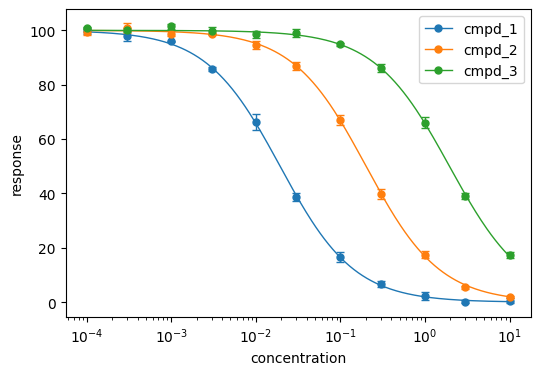

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_compounds(
    data,
    results,
    compounds=None,
    ax=ax,
)
ax.legend()
plt.show()

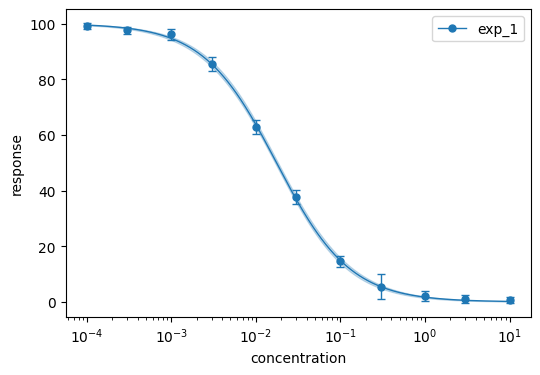

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(
    data,
    results,
    compounds="cmpd_1",
    confidence_band=True,
    ax=ax,
    experiments=["exp_1"],
)
ax.legend()
plt.show()

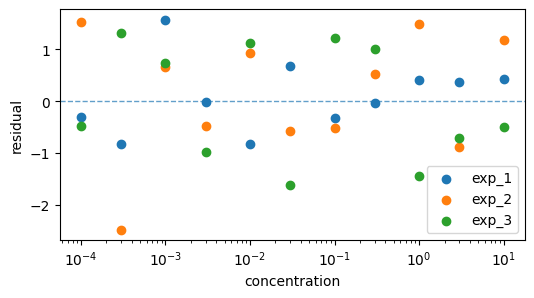

In [25]:
fig, ax = plt.subplots(figsize=(6, 3))
bc.plot_residuals(
    data, 
    results, 
    compound_id="cmpd_1", 
    ax=ax
)
ax.legend()
plt.show()